In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from scipy.optimize import minimize

In [2]:
# LOAD THE DATA
merged = pd.read_csv("nypd_merged_2025.csv")
deployment = pd.read_csv('nypd_deployment_2025.csv')

In [3]:
deployment = pd.read_csv('nypd_deployment_2025.csv')
deployment.columns = deployment.columns.str.lower()
deployment['arrest_precinct'] = pd.to_numeric(deployment['command'], errors='coerce')
deployment.loc[deployment['command'] == 'Central Park', 'arrest_precinct'] = 22

In [4]:
print(merged.columns.tolist())

['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC', 'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'Location', 'year', 'month', 'day', 'day_of_week', 'weekend', 'LAW_CAT_CD_9', 'LAW_CAT_CD_F', 'LAW_CAT_CD_I', 'LAW_CAT_CD_M', 'LAW_CAT_CD_V', 'LAW_CAT_CD_nan', 'ARREST_BORO_B', 'ARREST_BORO_K', 'ARREST_BORO_M', 'ARREST_BORO_Q', 'ARREST_BORO_S', 'Total', '% of Command', 'Bureau', 'Viper']


NEED TO ALSO LOAD THE PRECINT DATASET SO WE CAN MAP GRID CELLS TO THE NEAREST PRECINT.. POTENTIAL CODE BELOW ONCE WE HAVE IT!

To estimate deployment influence, you must transform raw points into a Density Map.
- Define a Grid: Create a bounding box for NYC and divide it into cells 
- Nearest Precinct: Calculate the centroid of each cell and find the Euclidean distance to the nearest Precinct station.
- Map Deployment: Merge your parsed PDF data (officers per precinct) to each grid cell based on its assigned precinct.

In [7]:
precinct_locations = merged.groupby('ARREST_PRECINCT').agg(
    precinct_lat=('Latitude', 'mean'),
    precinct_lon=('Longitude', 'mean'),
    officers_assigned=('Total', 'first')
).reset_index().rename(columns={'ARREST_PRECINCT': 'precinct'})

print(precinct_locations.head())
print("Shape:", precinct_locations.shape)

   precinct  precinct_lat  precinct_lon  officers_assigned
0         1     40.717450    -74.006879                  4
1         5     40.717028    -73.998189                  1
2         6     40.733681    -74.001070                  4
3         7     40.716748    -73.985584                  0
4         9     40.726039    -73.986443                  1
Shape: (78, 4)


In [11]:
# Create grid cells from latitude/longitude

#LAT LONG TO NUMERIC
merged['Latitude'] = pd.to_numeric(merged['Latitude'], errors='coerce')
merged['Longitude'] = pd.to_numeric(merged['Longitude'], errors='coerce')

#DROP BAD COORDINATES
merged = merged.dropna(subset=['Latitude', 'Longitude'])
merged = merged[(merged['Latitude'] != 0) & (merged['Longitude'] != 0)]

#GRID CELLS
merged['lat_grid'] = merged['Latitude'].round(3)
merged['lon_grid'] = merged['Longitude'].round(3)

#GRID ID
merged['grid_id'] = (
    merged['lat_grid'].astype(str) + "_" + merged['lon_grid'].astype(str)
)

print(merged[['Latitude', 'Longitude', 'lat_grid', 'lon_grid', 'grid_id']].head())
print("Unique grid cells:", merged['grid_id'].nunique())

    Latitude  Longitude  lat_grid  lon_grid         grid_id
0  40.744989 -73.870145    40.745   -73.870   40.745_-73.87
1  40.668798 -73.931120    40.669   -73.931  40.669_-73.931
2  40.844152 -73.900500    40.844   -73.900    40.844_-73.9
3  40.807102 -73.943874    40.807   -73.944  40.807_-73.944
4  40.864401 -73.829711    40.864   -73.830   40.864_-73.83
Unique grid cells: 14628


In [12]:
grid_points = merged[["grid_id", "lat_grid", "lon_grid"]].drop_duplicates().dropna()

precinct_coords = np.radians(precinct_locations[["precinct_lat", "precinct_lon"]])
grid_coords = np.radians(grid_points[["lat_grid", "lon_grid"]])

tree = BallTree(precinct_coords, metric="haversine")
dist, ind = tree.query(grid_coords, k=1)

grid_points["nearest_precinct"] = precinct_locations.iloc[ind.flatten()]["precinct"].values
grid_points["estimated_officers"] = precinct_locations.iloc[ind.flatten()]["officers_assigned"].values

print(grid_points.head())

          grid_id  lat_grid  lon_grid  nearest_precinct  estimated_officers
0   40.745_-73.87    40.745   -73.870               110                   6
1  40.669_-73.931    40.669   -73.931                77                   3
2    40.844_-73.9    40.844   -73.900                48                  17
3  40.807_-73.944    40.807   -73.944                28                  10
4   40.864_-73.83    40.864   -73.830                49                  10


In [14]:
# Merge nearest precinct/officer info back onto each arrest row
merged = merged.merge(
    grid_points[['grid_id', 'nearest_precinct', 'estimated_officers']],
    on='grid_id',
    how='left'
)

# Aggregate arrests to daily grid level
daily_grid = merged.groupby(
    ['grid_id', 'ARREST_DATE']
).agg({
    'ARREST_KEY': 'count',
    'ARREST_PRECINCT': 'first',
    'ARREST_BORO': 'first',
    'nearest_precinct': 'first',
    'estimated_officers': 'first',
    'Total': 'first',
    '% of Command': 'first',
    'Bureau': 'first',
    'Viper': 'first'
}).reset_index()

# Rename arrest count
daily_grid = daily_grid.rename(columns={
    'ARREST_KEY': 'crime_count',
    'Total': 'total',
    '% of Command': '% of command',
    'Bureau': 'bureau',
    'Viper': 'viper'
})

print(daily_grid.head())
print("Shape:", daily_grid.shape)

          grid_id ARREST_DATE  crime_count  ARREST_PRECINCT ARREST_BORO  \
0   40.505_-74.24  2026-02-25            1              123           S   
1  40.507_-74.235  2026-02-28            2              123           S   
2  40.507_-74.236  2026-03-21            1              123           S   
3  40.507_-74.253  2026-03-03            1              123           S   
4  40.507_-74.253  2026-03-18            1              123           S   

   nearest_precinct  estimated_officers  total  % of command bureau  viper  
0               123                   2      2           1.8   PBSI  False  
1               123                   2      2           1.8   PBSI  False  
2               123                   2      2           1.8   PBSI  False  
3               123                   2      2           1.8   PBSI  False  
4               123                   2      2           1.8   PBSI  False  
Shape: (44937, 11)


In [15]:
daily_grid = daily_grid[daily_grid['grid_id'] != '0.0_0.0']

daily_grid['ARREST_DATE'] = pd.to_datetime(daily_grid['ARREST_DATE'])
daily_grid['month'] = daily_grid['ARREST_DATE'].dt.month
daily_grid['day_of_week'] = daily_grid['ARREST_DATE'].dt.dayofweek
daily_grid['weekend'] = daily_grid['day_of_week'].isin([5, 6]).astype(int)
daily_grid['week_of_year'] = daily_grid['ARREST_DATE'].dt.isocalendar().week.astype(int)
daily_grid['year'] = daily_grid['ARREST_DATE'].dt.year

daily_grid = daily_grid.sort_values(['grid_id', 'ARREST_DATE'])
daily_grid['lag_1d']  = daily_grid.groupby('grid_id')['crime_count'].shift(1)
daily_grid['lag_7d']  = daily_grid.groupby('grid_id')['crime_count'].shift(7)
daily_grid['lag_30d'] = daily_grid.groupby('grid_id')['crime_count'].shift(30)
daily_grid['rolling_7d_mean']  = daily_grid.groupby('grid_id')['crime_count'].transform(lambda x: x.shift(1).rolling(7).mean())
daily_grid['rolling_30d_mean'] = daily_grid.groupby('grid_id')['crime_count'].transform(lambda x: x.shift(1).rolling(30).mean())

daily_grid = daily_grid.dropna(subset=['lag_1d', 'lag_7d', 'lag_30d', 'bureau'])

print("Shape:", daily_grid.shape)
print("\nDate range:", daily_grid['ARREST_DATE'].min(), "→", daily_grid['ARREST_DATE'].max())
print("\nMissing values:\n", daily_grid.isnull().sum())

Shape: (4514, 21)

Date range: 2026-01-31 00:00:00 → 2026-03-31 00:00:00

Missing values:
 grid_id               0
ARREST_DATE           0
crime_count           0
ARREST_PRECINCT       0
ARREST_BORO           0
nearest_precinct      0
estimated_officers    0
total                 0
% of command          0
bureau                0
viper                 0
month                 0
day_of_week           0
weekend               0
week_of_year          0
year                  0
lag_1d                0
lag_7d                0
lag_30d               0
rolling_7d_mean       0
rolling_30d_mean      0
dtype: int64


In [16]:
daily_grid = daily_grid.dropna(subset=['nearest_precinct'])
print("Final shape:", daily_grid.shape)

Final shape: (4514, 21)


Train: 254760 rows | Test: 63625 rows
Cutoff date: 2025-06-28

RF (no deployment):
  MAE: 1.0510
  R2:  0.3531

RF (with deployment):
  MAE: 1.0528
  R2:  0.3554

XGB (no deployment):
  MAE: 0.9707
  R2:  0.4047

XGB (with deployment):
  MAE: 0.9698
  R2:  0.4056

                 Model    MAE     R2
   RF (no deployment) 1.0510 0.3531
 RF (with deployment) 1.0528 0.3554
  XGB (no deployment) 0.9707 0.4047
XGB (with deployment) 0.9698 0.4056


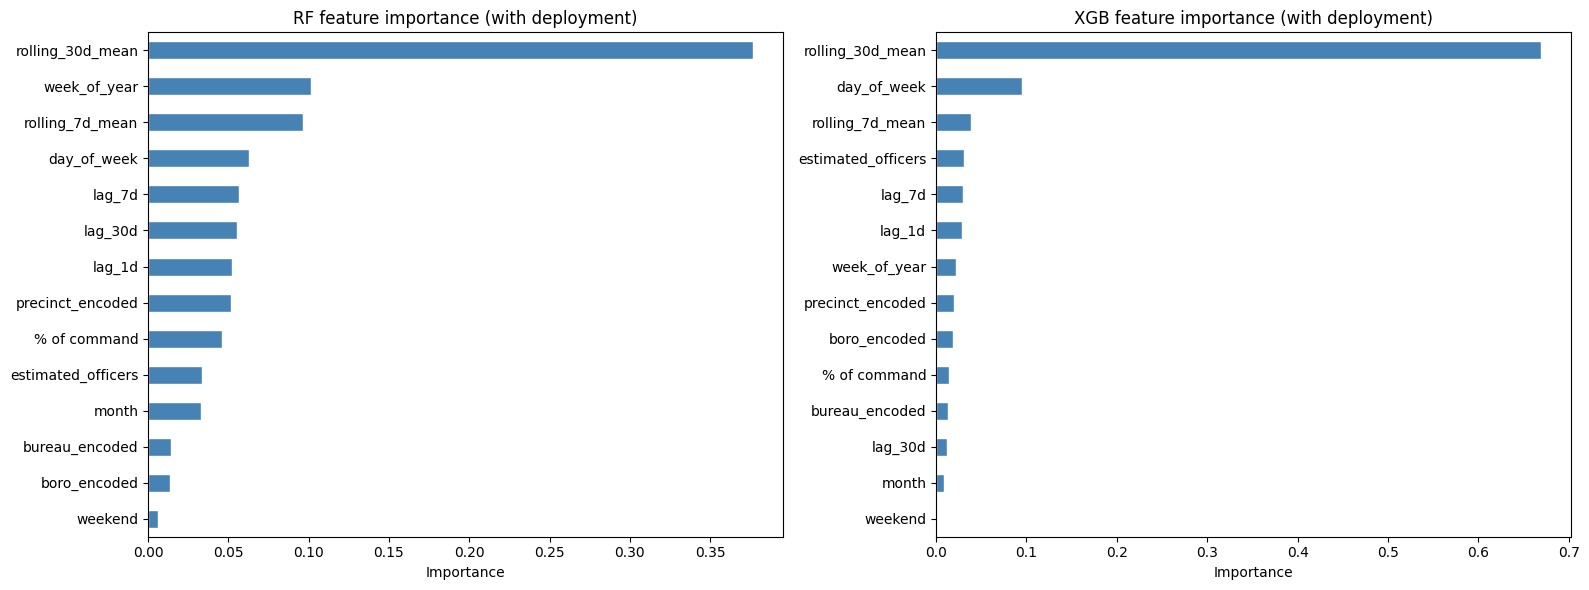

In [118]:
# ── 1. encode categoricals ───────────────────────────────────────────────────
le_boro = LabelEncoder()
le_bureau = LabelEncoder()
daily_grid['boro_encoded'] = le_boro.fit_transform(daily_grid['ARREST_BORO'].astype(str))
daily_grid['precinct_encoded'] = LabelEncoder().fit_transform(daily_grid['nearest_precinct'].astype(str))
daily_grid['bureau_encoded'] = le_bureau.fit_transform(daily_grid['bureau'].astype(str))
deployment_features = base_features + ['estimated_officers', '% of command']

# ── 2. feature sets ──────────────────────────────────────────────────────────
base_features = [
    'month', 'day_of_week', 'weekend', 'week_of_year',
    'boro_encoded', 'bureau_encoded', 'precinct_encoded',
    'lag_1d', 'lag_7d', 'lag_30d',
    'rolling_7d_mean', 'rolling_30d_mean'
]


target = 'crime_count'

# ── 3. time-based train/test split ───────────────────────────────────────────
daily_grid = daily_grid.sort_values('ARREST_DATE')
cutoff = daily_grid['ARREST_DATE'].quantile(0.8)

train = daily_grid[daily_grid['ARREST_DATE'] <= cutoff]
test  = daily_grid[daily_grid['ARREST_DATE'] > cutoff]

X_train_base = train[base_features]
X_test_base  = test[base_features]
X_train_dep  = train[deployment_features]
X_test_dep   = test[deployment_features]
y_train      = train[target]
y_test       = test[target]

print(f"Train: {len(train)} rows | Test: {len(test)} rows")
print(f"Cutoff date: {cutoff.date()}")

# ── 4. random forest without deployment ──────────────────────────────────────
rf_base = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_base.fit(X_train_base, y_train)
rf_base_preds = rf_base.predict(X_test_base)

print("\nRF (no deployment):")
print(f"  MAE: {mean_absolute_error(y_test, rf_base_preds):.4f}")
print(f"  R2:  {r2_score(y_test, rf_base_preds):.4f}")

# ── 5. random forest with deployment ─────────────────────────────────────────
rf_dep = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_dep.fit(X_train_dep, y_train)
rf_dep_preds = rf_dep.predict(X_test_dep)

print("\nRF (with deployment):")
print(f"  MAE: {mean_absolute_error(y_test, rf_dep_preds):.4f}")
print(f"  R2:  {r2_score(y_test, rf_dep_preds):.4f}")

# ── 6. xgboost without deployment ────────────────────────────────────────────
xgb_base = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                              random_state=42, n_jobs=-1, verbosity=0)
xgb_base.fit(X_train_base, y_train)
xgb_base_preds = xgb_base.predict(X_test_base)

print("\nXGB (no deployment):")
print(f"  MAE: {mean_absolute_error(y_test, xgb_base_preds):.4f}")
print(f"  R2:  {r2_score(y_test, xgb_base_preds):.4f}")

# ── 7. xgboost with deployment ────────────────────────────────────────────────
xgb_dep = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                             random_state=42, n_jobs=-1, verbosity=0)
xgb_dep.fit(X_train_dep, y_train)
xgb_dep_preds = xgb_dep.predict(X_test_dep)

print("\nXGB (with deployment):")
print(f"  MAE: {mean_absolute_error(y_test, xgb_dep_preds):.4f}")
print(f"  R2:  {r2_score(y_test, xgb_dep_preds):.4f}")

# ── 8. results summary ────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['RF (no deployment)', 'RF (with deployment)', 
              'XGB (no deployment)', 'XGB (with deployment)'],
    'MAE':   [mean_absolute_error(y_test, rf_base_preds),
              mean_absolute_error(y_test, rf_dep_preds),
              mean_absolute_error(y_test, xgb_base_preds),
              mean_absolute_error(y_test, xgb_dep_preds)],
    'R2':    [r2_score(y_test, rf_base_preds),
              r2_score(y_test, rf_dep_preds),
              r2_score(y_test, xgb_base_preds),
              r2_score(y_test, xgb_dep_preds)]
}).round(4)

print("\n", results.to_string(index=False))

# ── 9. feature importance plots ───────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title, features in [
    (axes[0], rf_dep,  'RF feature importance (with deployment)',  deployment_features),
    (axes[1], xgb_dep, 'XGB feature importance (with deployment)', deployment_features)
]:
    importances = pd.Series(model.feature_importances_, index=features).sort_values()
    importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Importance')
    ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [122]:
#what's actually driving predictions
importances_xgb = pd.Series(
    xgb_dep.feature_importances_, 
    index=deployment_features
).sort_values(ascending=False)

print("XGB feature importances (with deployment):")
print(importances_xgb.round(4).to_string())

# variance in the target
print("\nCrime count distribution:")
print(daily_grid['crime_count'].describe().round(2))

#date range
print("\nDate range:", daily_grid['ARREST_DATE'].min(), "→", daily_grid['ARREST_DATE'].max())

XGB feature importances (with deployment):
rolling_30d_mean      0.6690
day_of_week           0.0956
rolling_7d_mean       0.0388
estimated_officers    0.0306
lag_7d                0.0295
lag_1d                0.0283
week_of_year          0.0218
precinct_encoded      0.0195
boro_encoded          0.0185
% of command          0.0142
bureau_encoded        0.0134
lag_30d               0.0119
month                 0.0091
weekend               0.0000

Crime count distribution:
count    318385.00
mean          2.10
std           2.11
min           1.00
25%           1.00
50%           1.00
75%           2.00
max         138.00
Name: crime_count, dtype: float64

Date range: 2023-01-31 00:00:00 → 2025-12-31 00:00:00


In [124]:
print(daily_grid['ARREST_DATE'].value_counts().sort_index().head(20))
print("\nUnique dates:", daily_grid['ARREST_DATE'].nunique())
print("Unique grid cells:", daily_grid['grid_id'].nunique())

ARREST_DATE
2023-01-31     2
2023-02-01     5
2023-02-02     9
2023-02-03    12
2023-02-04    15
2023-02-05    22
2023-02-06    29
2023-02-07    42
2023-02-08    47
2023-02-09    51
2023-02-10    58
2023-02-11    57
2023-02-12    49
2023-02-13    57
2023-02-14    66
2023-02-15    86
2023-02-16    82
2023-02-17    78
2023-02-18    68
2023-02-19    47
Name: count, dtype: int64

Unique dates: 1066
Unique grid cells: 1854


FOR MODELING TARGET VARIABLE WILL BE CRIME COUNT WITH FEATURES LIKE DEPLOYED FORCES, DAY OF WEEK, MONTH, OTHER TEMPORAL, BOROUGH, PRECINT, LAGGED CRIME (YESTERDAY, 7 DAYS, 30 DAYS)!! RUN A RANDOM FOREST/XGBOOST WITH DEPLOYED FORCES AND WITHOUT
- MAYBE INCLUDE A CONSTRAINT THAT HAS A MINIMUM DEPLOYMENT FLOOR OR PENALTY FOR OVER-CONCENTRATION